# 🔀 Parallel Search Agent with LangGraph
> **Wikipedia + Arxiv running at the same time — step-by-step walkthrough**

This notebook builds a research agent that queries two sources simultaneously:
- **Wikipedia** — for general background knowledge
- **Arxiv** — for academic papers

We use **LangGraph** to define the flow as a graph of nodes, and **ThreadPoolExecutor** to run both searches in parallel within a single node (avoiding LangGraph's fan-in loop bug).

---
### 📐 Graph shape
```
START
  │
  ▼
parallel_search_node   ← Wikipedia + Arxiv run HERE, concurrently
  │
  ▼
combine_node           ← merges both results into one string
  │
  ▼
 END
```

---

## ⚙️ Step 1 — Install dependencies

| Package | Why we need it |
|---|---|
| `langgraph` | Defines and runs the graph (nodes + edges) |
| `langchain-community` | Provides ready-made tool wrappers for Wikipedia and Arxiv |
| `langchain-google-genai` | LangChain wrapper for Google Gemini — powers the summarisation step |
| `wikipedia` | The actual Wikipedia API client (used internally by LangChain) |
| `arxiv` | The actual Arxiv API client (used internally by LangChain) |

In [1]:
%pip install -q wikipedia arxiv langgraph langchain-community langchain-google-genai

Note: you may need to restart the kernel to use updated packages.


c:\Users\r1005\Downloads\langbasic\.venv\Scripts\python.exe: No module named pip


## 📦 Step 2 — Imports

We only need a handful of things:

- `ThreadPoolExecutor` + `as_completed` → runs our two fetch functions on separate threads so they happen at the same time
- `TypedDict` → gives our state dictionary type hints (LangGraph uses this to know what keys exist)
- `StateGraph`, `START`, `END` → LangGraph's core building blocks
- Wikipedia/Arxiv wrappers → thin clients that call each API and return plain text

In [2]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import TypedDict

from langgraph.graph import StateGraph, START, END

# Wikipedia
from langchain_community.tools.wikipedia.tool import WikipediaQueryRun
from langchain_community.utilities.wikipedia import WikipediaAPIWrapper

# Arxiv
from langchain_community.tools.arxiv.tool import ArxivQueryRun
from langchain_community.utilities.arxiv import ArxivAPIWrapper

# Gemini LLM  (imported here, initialised in Step 4)
from langchain_google_genai import ChatGoogleGenerativeAI as Gai

print("✅ All imports successful")

✅ All imports successful


## 🔧 Step 3 — Create the tools

Each tool is a wrapper around its API. The key settings are:

| Parameter | Meaning |
|---|---|
| `top_k_results=2` | Return only the top 2 results (keeps responses short) |
| `doc_content_chars_max=500` | Truncate each result to 500 characters |

Calling `wiki.run("some query")` returns a plain Python string.
Calling `arxiv.run("some query")` does the same.

Both tools are **stateless** — they can be safely called from multiple threads simultaneously.

In [3]:
wiki = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(
        top_k_results=2,
        doc_content_chars_max=500,
    )
)

arxiv = ArxivQueryRun(
    api_wrapper=ArxivAPIWrapper(
        top_k_results=2,
        doc_content_chars_max=500,
    )
)

print("✅ Tools created")

# Quick smoke test (optional — comment out to skip)
print("\n🔍 Wikipedia smoke test:")
print(wiki.run("Python programming language")[:200], "...")

✅ Tools created

🔍 Wikipedia smoke test:
Page: Python (programming language)
Summary: Python is a high-level, general-purpose programming language that emphasizes code readability, simplicity, and ease-of-writing with the use of significant  ...


## 🤖 Step 4 — Set up the Gemini LLM

We add **Gemini 2.5 Flash Lite** as the summarisation brain that reads both raw search results and produces a clean, concise answer.

### Install
`langchain-google-genai` is the LangChain wrapper around Google's Gemini API.
You'll also need a **Google API key** — get one free at [aistudio.google.com](https://aistudio.google.com).

```
GOOGLE_API_KEY=your_key_here   ← set this in your environment
```

### Model settings

| Parameter | Value | Meaning |
|---|---|---|
| `model` | `gemini-2.5-flash-lite` | Fast, cheap Gemini model — good for short summarisation tasks |
| `temperature` | `0.5` | Balanced between creative and factual (0 = deterministic, 1 = creative) |
| `max_output_tokens` | `300` | Cap the response at ~300 tokens to keep summaries tight |
| `top_k` | `3` | At each step only consider the 3 most likely next tokens — keeps output focused |

In [4]:
%pip install -q langchain-google-genai

Note: you may need to restart the kernel to use updated packages.


c:\Users\r1005\Downloads\langbasic\.venv\Scripts\python.exe: No module named pip


In [5]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI as Gai

# Set your Google API key — either paste it here or load from environment
# os.environ["GOOGLE_API_KEY"] = "your_key_here"  # ← uncomment and fill in

llm = Gai(
    model="gemini-2.5-flash-lite",
    temperature=0.5,
    max_output_tokens=300,
    top_k=3,
)

print("✅ Gemini LLM ready")
print(f"   Model : {llm.model}")
print(f"   Temp  : {llm.temperature}")
print(f"   Tokens: {llm.max_output_tokens}")
print(f"   Top-k : {llm.top_k}")

✅ Gemini LLM ready
   Model : gemini-2.5-flash-lite
   Temp  : 0.5
   Tokens: 300
   Top-k : 3


## 🗂️ Step 5 — Define the State

In LangGraph, **State** is a shared dictionary that flows through every node.
Each node *receives* the current state and *returns* a partial update (only the keys it changed).

```
State {
    query        → the search term the user provides
    wiki_result  → filled in by the parallel search node
    arxiv_result → filled in by the parallel search node
    final_result → filled in by the combine node
}
```

> 💡 Using `TypedDict` is optional but strongly recommended — it makes autocomplete work and prevents typos in key names.

In [6]:
class State(TypedDict):
    query:        str   # Input: provided by the user
    wiki_result:  str   # Output of Wikipedia search
    arxiv_result: str   # Output of Arxiv search
    final_result: str   # Combined + LLM-summarised output

print("✅ State schema defined")
print("   Keys:", list(State.__annotations__.keys()))

✅ State schema defined
   Keys: ['query', 'wiki_result', 'arxiv_result', 'final_result']


## 🔀 Step 6 — Build the parallel search node

This is the most important node. It fires both tools **at the same time** using Python's `ThreadPoolExecutor`.

### How it works:

```
parallel_search_node(state)
│
├─── Thread 1: fetch_wiki()  ──► calls wiki.run(query)
│                                 ↳ returns ("wiki_result", text)
│
└─── Thread 2: fetch_arxiv() ──► calls arxiv.run(query)
                                  ↳ returns ("arxiv_result", text)
│
Both threads run at the same time. as_completed() yields
whichever finishes first — no blocking, no ordering assumed.
│
Returns: { "wiki_result": ..., "arxiv_result": ... }
```

### Why not two separate LangGraph nodes?
If you put `wiki_node` and `arxiv_node` as separate nodes both pointing to a `combine_node`, LangGraph calls `combine_node` **once per incoming edge** — so it runs twice, writes partial state back, and re-triggers upstream nodes → **infinite loop**.
Keeping parallelism inside one node avoids this entirely.

### Fault isolation:
Each inner function (`fetch_wiki`, `fetch_arxiv`) wraps its call in `try/except`. If Wikipedia is down, you still get the Arxiv result — and vice versa.

In [7]:
def parallel_search_node(state: State) -> dict:
    """
    Runs Wikipedia and Arxiv searches concurrently.
    If one fails the other still returns its result.
    """
    print("\n===== RUNNING WIKIPEDIA + ARXIV IN PARALLEL =====")
    query = state["query"]
    results = {}

    # ── Inner fetch functions ──────────────────────────────────
    # Each returns a (key, value) tuple so we can identify
    # which result came back without relying on ordering.

    def fetch_wiki() -> tuple[str, str]:
        try:
            return "wiki_result", wiki.run(query)
        except Exception as exc:
            return "wiki_result", f"[Wikipedia Error] {exc}"

    def fetch_arxiv() -> tuple[str, str]:
        try:
            return "arxiv_result", arxiv.run(query)
        except Exception as exc:
            return "arxiv_result", f"[Arxiv Error] {exc}"

    # ── Launch both on a thread pool ──────────────────────────
    # max_workers=2 means both threads start immediately.
    # as_completed() yields futures as they finish (fastest first).

    with ThreadPoolExecutor(max_workers=2) as pool:
        futures = {
            pool.submit(fetch_wiki):  "Wikipedia",
            pool.submit(fetch_arxiv): "Arxiv",
        }
        for future in as_completed(futures):
            source = futures[future]
            try:
                key, value = future.result()
                results[key] = value
                print(f"  ✓ {source} finished")
            except Exception as exc:
                label = "wiki_result" if source == "Wikipedia" else "arxiv_result"
                results[label] = f"[{source} Error] {exc}"
                print(f"  ✗ {source} failed: {exc}")

    return results  # LangGraph merges this into the shared State

print("✅ parallel_search_node defined")

✅ parallel_search_node defined


## 🧩 Step 7 — Build the combine node (with LLM summarisation)

Now that we have a Gemini LLM, the combine node does two things:

1. **Formats** both raw results into a structured prompt
2. **Calls the LLM** to produce a single concise summary paragraph

```
wiki_result  ──┐
               ├──► prompt ──► llm.invoke() ──► final_result
arxiv_result ──┘
```

The raw results are still preserved in state (`wiki_result`, `arxiv_result`) — only `final_result` is the LLM summary.

In [8]:
def combine_node(state: State) -> dict:
    """Feeds both search results into Gemini and returns a concise summary."""
    print("\n===== COMBINING + SUMMARISING WITH GEMINI =====")

    wiki  = state.get('wiki_result',  'No Wikipedia result')
    arxiv = state.get('arxiv_result', 'No Arxiv result')

    # ── Build the prompt ────────────────────────────────────────
    # We give the LLM both raw sources and ask for a tight summary.
    prompt = (
        f"You are a research assistant. Using ONLY the two sources below, "
        f"write a concise 3-5 sentence summary about: {state['query']}\n\n"
        f"=== Wikipedia ===\n{wiki}\n\n"
        f"=== Arxiv ===\n{arxiv}\n\n"
        f"Summary:"
    )

    # ── Call Gemini ──────────────────────────────────────────────
    try:
        response = llm.invoke(prompt)          # returns an AIMessage
        summary  = response.content.strip()    # extract the text
    except Exception as exc:
        summary = f"[LLM Error] {exc}\n\nRaw results:\n{wiki}\n\n{arxiv}"

    final = (
        f"=== LLM Summary (Gemini 2.5 Flash Lite) ===\n{summary}\n\n"
        f"--- Wikipedia (raw) ---\n{wiki}\n\n"
        f"--- Arxiv (raw) ---\n{arxiv}"
    )
    return {"final_result": final}

print("✅ combine_node defined (with LLM summarisation)")

✅ combine_node defined (with LLM summarisation)


## 🏗️ Step 8 — Build and compile the graph

LangGraph uses a **builder pattern**:
1. Create a `StateGraph` and tell it which state class to use
2. Add nodes (name → function)
3. Add edges (source → destination)
4. Compile into a runnable graph

### Edge map:
```
START  ──►  parallel_search  ──►  combine  ──►  END
```

> 📌 `START` and `END` are special sentinel nodes built into LangGraph — you don't add them manually, you just connect to/from them.

In [9]:
# ── 1. Create builder ───────────────────────────────────────────
builder = StateGraph(State)

# ── 2. Register nodes ───────────────────────────────────────────
builder.add_node("parallel_search", parallel_search_node)
builder.add_node("combine",         combine_node)

# ── 3. Wire edges ───────────────────────────────────────────────
builder.add_edge(START,             "parallel_search")  # entry point
builder.add_edge("parallel_search", "combine")          # search → merge
builder.add_edge("combine",         END)                 # merge → done

# ── 4. Compile ──────────────────────────────────────────────────
graph = builder.compile()

print("✅ Graph compiled successfully")
print("   Nodes:", list(graph.nodes))

✅ Graph compiled successfully
   Nodes: ['__start__', 'parallel_search', 'combine']


## 🗺️ Step 8 — Visualise the graph with Mermaid

LangGraph can render your compiled graph as a **Mermaid diagram** right inside the notebook.

### How it works:
```
graph.get_graph()            → returns the internal CGraph object
  .draw_mermaid_png()        → sends the Mermaid source to mermaid.ink
                               and gets back raw PNG bytes
IPython Image(...)           → renders those bytes as an inline image
display(...)                 → tells Jupyter to show it in the cell output
```

> 💡 `draw_mermaid_png()` calls the free **mermaid.ink** public API under the hood,
> so you need an internet connection. No extra install required.

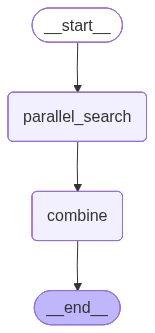

In [10]:
from IPython.display import Image, display

# Render the compiled graph as a Mermaid PNG and display it inline
display(Image(graph.get_graph().draw_mermaid_png()))

### 🔎 What you're seeing

| Node | Colour | Role |
|---|---|---|
| `__start__` | Green rounded | Entry point — graph begins here |
| `parallel_search` | Blue box | Runs Wikipedia + Arxiv concurrently |
| `combine` | Blue box | Merges both results into `final_result` |
| `__end__` | Red rounded | Exit point — graph finishes here |

The arrows show the exact execution order LangGraph will follow when you call `graph.invoke()`.

---
#### Bonus — print the raw Mermaid source
If you want to see the underlying Mermaid text that generated the diagram:

In [11]:
# Print the raw Mermaid source LangGraph generated
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	parallel_search(parallel_search)
	combine(combine)
	__end__([<p>__end__</p>]):::last
	__start__ --> parallel_search;
	parallel_search --> combine;
	combine --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 🚀 Step 9 — Run the graph

`graph.invoke(initial_state)` kicks off execution from `START`.
It blocks until `END` is reached and returns the **final full state dictionary**.

The initial state only needs `query` — the other keys (`wiki_result`, `arxiv_result`, `final_result`) are populated as nodes run.

### Execution trace:
```
invoke({ "query": "Quantum Computing" })
   │
   1. parallel_search_node runs
      │  Thread 1: wiki.run()  ──┐
      │  Thread 2: arxiv.run() ──┘ (both at once)
      └─► state["wiki_result"]  = "..."
          state["arxiv_result"] = "..."
   │
   2. combine_node runs
      └─► state["final_result"] = formatted string
   │
   3. Returns full state dict
```

In [12]:
result = graph.invoke({"query": "Quantum Computing"})

print("\n✅ Graph execution complete")


===== RUNNING WIKIPEDIA + ARXIV IN PARALLEL =====
  ✓ Wikipedia finished
  ✓ Arxiv finished

===== COMBINING + SUMMARISING WITH GEMINI =====

✅ Graph execution complete


## 📋 Step 10 — Inspect the results

The returned `result` dict contains all four state keys.
Let's look at each one individually, then print the formatted final output.

In [13]:
# What keys came back?
print("State keys returned:", list(result.keys()))

State keys returned: ['query', 'wiki_result', 'arxiv_result', 'final_result']


In [14]:
# Wikipedia result
print("=== WIKIPEDIA RESULT ===")
print(result["wiki_result"])

=== WIKIPEDIA RESULT ===
Page: Quantum computing
Summary: A quantum computer is a real or theoretical computer that exploits quantum phenomena like superposition and entanglement in an essential way. It is widely believed that a quantum computer could perform some calculations exponentially faster than any classical computer. For example, a large-scale quantum computer could break some widely used encryption schemes and aid physicists in performing physical simulations. However, current hardware implementations of quant


In [15]:
# Arxiv result
print("=== ARXIV RESULT ===")
print(result["arxiv_result"])

=== ARXIV RESULT ===
Published: 2022-11-04
Title: Tierkreis: A Dataflow Framework for Hybrid Quantum-Classical Computing
Authors: Seyon Sivarajah, Lukas Heidemann, Alan Lawrence, Ross Duncan
Summary: We present Tierkreis, a higher-order dataflow graph program representation and runtime designed for compositional, quantum-classical hybrid algorithms. The design of the system is motivated by the remote nature of quantum computers, the need for hybrid algorithms to involve cloud and distributed computing, and the long-


In [16]:
# Final combined output
print("================ FINAL OUTPUT ================")
print(result["final_result"])

================ FINAL OUTPUT ================
=== LLM Summary (Gemini 2.5 Flash Lite) ===
Quantum computing utilizes quantum phenomena such as superposition and entanglement to perform calculations, potentially offering exponential speedups over classical computers for specific tasks. These advancements could lead to the breaking of current encryption methods and enable more accurate physical simulations. While theoretical, research is ongoing into hardware implementations and frameworks like Tierkreis, which support compositional, quantum-classical hybrid algorithms for distributed computing environments.

--- Wikipedia (raw) ---
Page: Quantum computing
Summary: A quantum computer is a real or theoretical computer that exploits quantum phenomena like superposition and entanglement in an essential way. It is widely believed that a quantum computer could perform some calculations exponentially faster than any classical computer. For example, a large-scale quantum computer could break s

## 🔁 Step 11 — Try your own query

Just change the `query` string and re-run the cell.

In [17]:
# ✏️  Change this to anything you want to research
my_query = "Large Language Models"

my_result = graph.invoke({"query": my_query})
print(my_result["final_result"])


===== RUNNING WIKIPEDIA + ARXIV IN PARALLEL =====
  ✓ Wikipedia finished
  ✓ Arxiv finished

===== COMBINING + SUMMARISING WITH GEMINI =====
=== LLM Summary (Gemini 2.5 Flash Lite) ===
Large language models (LLMs) are neural networks trained on extensive text data to perform natural language processing tasks like generation and summarization, forming the basis of modern chatbots. While capable of generating, translating, and parsing text, their reliability can be compromised by biased or inaccurate training data. Research is ongoing to enhance LLMs' human-like qualities, focusing on improving natural language understanding, conversational coherence, and emotional intelligence through methods like fine-tuning and incorporating psychological principles.

--- Wikipedia (raw) ---
Page: Large language model
Summary: A large language model (LLM) is a neural network trained on a vast amount of text for natural language processing tasks, especially language generation. LLMs can generate, summ

---
## 📌 Key takeaways

| Concept | What you learned |
|---|---|
| `StateGraph` | Defines a DAG where each node is a Python function |
| `TypedDict` | Gives the shared state dict type safety |
| `ThreadPoolExecutor` | Runs multiple I/O tasks at the same time within one node |
| `as_completed()` | Yields futures as they finish — handles whichever is fastest |
| Fan-in bug | Adding two edges → same node causes it to run twice; keep parallelism *inside* one node instead |
| Error isolation | Each fetch wraps its own exception so one failure never blocks the other |
| `ChatGoogleGenerativeAI` | LangChain wrapper for Gemini — `llm.invoke(prompt)` returns an `AIMessage`; `.content` is the text |

---
### 💡 Next steps to explore
- Add **conditional edges** (`add_conditional_edges`) to skip Arxiv if the query is non-technical
- Replace `graph.invoke()` with `graph.stream()` to see partial results as each node finishes
- Swap `gemini-2.5-flash-lite` for `gemini-2.5-flash` if you need longer or more detailed summaries